Mounted at /content/drive
🌽 CORN — PHASE 2: FINAL MASTER MODEL EVALUATION

Preprocessed dataset:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn/corn_processed_data.npz

Final trained model:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_mobilenetv2_final.keras

Evaluation output folder:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/Corn

CHECKING REQUIRED FILES
PASS: Preprocessed NPZ found
PASS: Final trained model found

LOADING PREPROCESSED TEST DATA

X_train: (1256, 224, 224, 3)
y_train: (1256,)

X_val: (269, 224, 224, 3)
y_val: (269,)

X_test: (270, 224, 224, 3)
y_test: (270,)

Evaluation dataset:
Test images = 270

CLASS MAPPING
0 -> Healthy
1 -> Common_Rust
2 -> Northern_Leaf_Blight

TEST DATA VERIFICATION
PASS: Test images = 270
PASS: Image shape = 224 × 224 × 3
PASS: RGB image structure verified
PASS: Pixel storage = uint8 [0,255]
PASS: Test labels = 0,

,precision,recall,f1-score,support
Healthy,0.9890,1.0000,0.9945,90.0000
Common_Rust,0.9773,0.9556,0.9663,90.0000
Northern_Leaf_Blight,0.9560,0.9667,0.9613,90.0000
accuracy,0.9741,0.9741,0.9741,0.9741
macro avg,0.9741,0.9741,0.9740,270.0000
weighted avg,0.9741,0.9741,0.9740,270.0000



Detailed classification report:
                      precision    recall  f1-score   support

             Healthy       0.99      1.00      0.99        90
         Common_Rust       0.98      0.96      0.97        90
Northern_Leaf_Blight       0.96      0.97      0.96        90

            accuracy                           0.97       270
           macro avg       0.97      0.97      0.97       270
        weighted avg       0.97      0.97      0.97       270


PER-CLASS ACCURACY
Healthy: 90/90 correct = 100.00%
Common_Rust: 86/90 correct = 95.56%
Northern_Leaf_Blight: 87/90 correct = 96.67%

Per-class results:


,class_id,class,total_images,correct,incorrect,accuracy,accuracy_percent,average_confidence,average_confidence_percent
0,0,Healthy,90,90,0,1.0000,100.0000,0.9919,99.1914
1,1,Common_Rust,90,86,4,0.9556,95.5556,0.9632,96.3172
2,2,Northern_Leaf_Blight,90,87,3,0.9667,96.6667,0.9444,94.4351



CONFUSION MATRIX

Rows = Actual
Columns = Predicted



,Healthy,Common_Rust,Northern_Leaf_Blight
Healthy,90,0,0
Common_Rust,0,86,4
Northern_Leaf_Blight,1,2,87


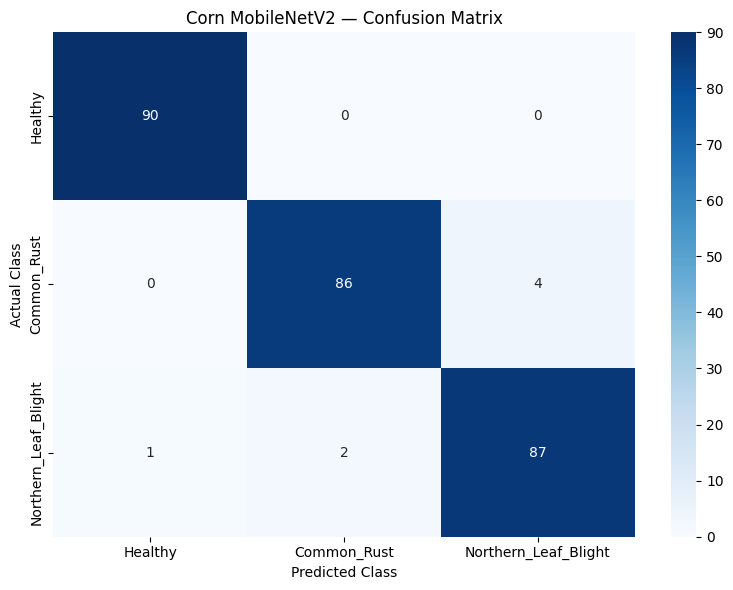

Confusion matrix saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/Corn/corn_confusion_matrix.png

Prediction-level results saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/Corn/corn_test_predictions.csv

ERROR ANALYSIS
Incorrect predictions: 7

Actual → Predicted errors:


,actual_class,predicted_class,count
0,Common_Rust,Northern_Leaf_Blight,4
1,Northern_Leaf_Blight,Common_Rust,2
2,Northern_Leaf_Blight,Healthy,1


Error summary saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation/Corn/corn_error_summary.csv

CONFIDENCE ANALYSIS
Average confidence          : 96.65%
Correct prediction average : 97.15%
Incorrect prediction average: 77.65%

🌽 CORN — MODEL EVALUATION FINAL AUDIT
PASS | Test set loaded
PASS | All 3 classes present
PASS | Correct image dimensions
PASS | Test labels match images
PASS | Test set not used for training
PASS | Predictions generated
PASS | Confusion matrix generated
PASS | Evaluation summary saved
PASS | Prediction CSV saved
PASS | Per-class results saved
PASS | Classification report saved
PASS | Confusion matrix saved

🎉 CORN — MODEL EVALUATION: PASS

FINAL TEST SET RESULTS
------------------------------------------------------------------------------------------
Test Accuracy       : 97.41%
Weighted Precision  : 97.41%
Weighted Recall     : 97.41%
Weighted F1-score   : 97.40%
Correct Predictions: 263/270
Incorrect Predictions: 7/270


In [1]:
# ================================================================
# 🌽 CORN — PHASE 2: FINAL MASTER MODEL EVALUATION
# ================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# 1. GOOGLE DRIVE
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
)

PREPROCESS_ROOT = DRIVE_ROOT / "3rd Preprocessing" / "Corn"
MODEL_ROOT = DRIVE_ROOT / "6th Trained_Model" / "Corn"
EVAL_ROOT = DRIVE_ROOT / "5th Model_Evaluation" / "Corn"

EVAL_ROOT.mkdir(parents=True, exist_ok=True)

NPZ_PATH = PREPROCESS_ROOT / "corn_processed_data.npz"
MODEL_PATH = MODEL_ROOT / "corn_mobilenetv2_final.keras"

print("=" * 90)
print("🌽 CORN — PHASE 2: FINAL MASTER MODEL EVALUATION")
print("=" * 90)

print("\nPreprocessed dataset:")
print(NPZ_PATH)

print("\nFinal trained model:")
print(MODEL_PATH)

print("\nEvaluation output folder:")
print(EVAL_ROOT)


# ================================================================
# 2. CHECK REQUIRED FILES
# ================================================================

print("\n" + "=" * 90)
print("CHECKING REQUIRED FILES")
print("=" * 90)

if not NPZ_PATH.exists():
    raise RuntimeError(
        f"STOP: Preprocessed dataset not found:\n{NPZ_PATH}"
    )

if not MODEL_PATH.exists():
    raise RuntimeError(
        f"STOP: Final trained model not found:\n{MODEL_PATH}"
    )

print("PASS: Preprocessed NPZ found")
print("PASS: Final trained model found")


# ================================================================
# 3. LOAD PREPROCESSED DATA
# ================================================================

print("\n" + "=" * 90)
print("LOADING PREPROCESSED TEST DATA")
print("=" * 90)

data = np.load(NPZ_PATH)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"\nX_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

print(f"\nX_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\nEvaluation dataset:")
print(f"Test images = {len(X_test)}")


# ================================================================
# 4. CLASS MAPPING
# ================================================================

CLASS_NAMES = [
    "Healthy",
    "Common_Rust",
    "Northern_Leaf_Blight"
]

NUM_CLASSES = len(CLASS_NAMES)

print("\n" + "=" * 90)
print("CLASS MAPPING")
print("=" * 90)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i} -> {name}")


# ================================================================
# 5. TEST DATA VERIFICATION
# ================================================================

print("\n" + "=" * 90)
print("TEST DATA VERIFICATION")
print("=" * 90)

if X_test.ndim != 4:
    raise RuntimeError(
        f"STOP: Unexpected X_test dimensions: {X_test.shape}"
    )

if X_test.shape[1:] != (224, 224, 3):
    raise RuntimeError(
        f"STOP: Expected test images (224,224,3), got {X_test.shape[1:]}"
    )

if len(X_test) != len(y_test):
    raise RuntimeError(
        "STOP: X_test and y_test lengths do not match."
    )

if not np.issubdtype(X_test.dtype, np.integer):
    raise RuntimeError(
        f"STOP: Unexpected X_test dtype: {X_test.dtype}"
    )

if X_test.min() < 0 or X_test.max() > 255:
    raise RuntimeError(
        "STOP: Test pixel range is outside [0,255]."
    )

unique_labels = sorted(np.unique(y_test).tolist())

if unique_labels != [0, 1, 2]:
    raise RuntimeError(
        f"STOP: Unexpected test labels: {unique_labels}"
    )

print("PASS: Test images = 270")
print("PASS: Image shape = 224 × 224 × 3")
print("PASS: RGB image structure verified")
print("PASS: Pixel storage = uint8 [0,255]")
print("PASS: Test labels = 0, 1, 2")
print("PASS: X_test and y_test match")


# ================================================================
# 6. TEST CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 90)
print("TEST SET CLASS DISTRIBUTION")
print("=" * 90)

test_distribution = pd.Series(y_test).value_counts().sort_index()

for class_id in range(NUM_CLASSES):
    count = int(test_distribution.get(class_id, 0))
    print(f"{class_id} -> {CLASS_NAMES[class_id]}: {count}")

print(f"\nTotal test images: {len(y_test)}")


# ================================================================
# 7. LOAD FINAL MODEL
# ================================================================

print("\n" + "=" * 90)
print("LOADING FINAL CORN MODEL")
print("=" * 90)

model = load_model(MODEL_PATH)

print("PASS: Final model loaded successfully")
print(f"Model path:\n{MODEL_PATH}")

print("\nModel input shape:")
print(model.input_shape)

print("\nModel output shape:")
print(model.output_shape)


# ================================================================
# 8. COMPILE FOR EVALUATION
# ================================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nPASS: Model compiled for evaluation")


# ================================================================
# 9. EVALUATE ON HELD-OUT TEST SET
# ================================================================

print("\n" + "=" * 90)
print("MODEL EVALUATION — HELD-OUT TEST SET")
print("=" * 90)

print("\nIMPORTANT:")
print("Only X_test / y_test are being used for final evaluation.")
print("Training and validation data are NOT used for final metrics.")

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)

print("\n" + "-" * 90)
print("TEST SET RESULTS")
print("-" * 90)

print(f"Test Loss     : {test_loss:.6f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


# ================================================================
# 10. GENERATE PREDICTIONS
# ================================================================

print("\n" + "=" * 90)
print("GENERATING TEST SET PREDICTIONS")
print("=" * 90)

probabilities = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(probabilities, axis=1)

confidence = np.max(probabilities, axis=1)

print("\nPASS: Predictions generated")
print(f"Prediction shape: {probabilities.shape}")


# ================================================================
# 11. CORRECT / INCORRECT PREDICTIONS
# ================================================================

correct_mask = y_pred == y_test

correct_predictions = int(np.sum(correct_mask))
incorrect_predictions = int(np.sum(~correct_mask))

calculated_accuracy = correct_predictions / len(y_test)

print("\n" + "=" * 90)
print("PREDICTION SUMMARY")
print("=" * 90)

print(f"Total test images       : {len(y_test)}")
print(f"Correct predictions     : {correct_predictions}")
print(f"Incorrect predictions   : {incorrect_predictions}")
print(f"Calculated accuracy     : {calculated_accuracy * 100:.2f}%")
print(f"Model evaluate accuracy : {test_accuracy * 100:.2f}%")


# ================================================================
# 12. PRECISION / RECALL / F1
# ================================================================

print("\n" + "=" * 90)
print("PRECISION — RECALL — F1-SCORE")
print("=" * 90)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Weighted Precision : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Weighted Recall    : {recall:.4f} ({recall * 100:.2f}%)")
print(f"Weighted F1-score  : {f1:.4f} ({f1 * 100:.2f}%)")


# ================================================================
# 13. PER-CLASS CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 90)
print("PER-CLASS PERFORMANCE")
print("=" * 90)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(
    report_df.round(4)
)

print("\nDetailed classification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)


# ================================================================
# 14. PER-CLASS ACCURACY
# ================================================================

print("\n" + "=" * 90)
print("PER-CLASS ACCURACY")
print("=" * 90)

per_class_results = []

for class_id, class_name in enumerate(CLASS_NAMES):

    class_mask = y_test == class_id

    total = int(np.sum(class_mask))
    correct = int(np.sum(y_pred[class_mask] == class_id))

    class_accuracy = correct / total if total > 0 else 0

    avg_conf = (
        float(np.mean(confidence[class_mask]))
        if total > 0 else 0
    )

    per_class_results.append({
        "class_id": class_id,
        "class": class_name,
        "total_images": total,
        "correct": correct,
        "incorrect": total - correct,
        "accuracy": class_accuracy,
        "accuracy_percent": class_accuracy * 100,
        "average_confidence": avg_conf,
        "average_confidence_percent": avg_conf * 100
    })

    print(
        f"{class_name}: "
        f"{correct}/{total} correct "
        f"= {class_accuracy * 100:.2f}%"
    )

per_class_df = pd.DataFrame(per_class_results)

print("\nPer-class results:")
display(
    per_class_df.round(4)
)


# ================================================================
# 15. CONFUSION MATRIX
# ================================================================

print("\n" + "=" * 90)
print("CONFUSION MATRIX")
print("=" * 90)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print("\nRows = Actual")
print("Columns = Predicted\n")

display(cm_df)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Corn MobileNetV2 — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

cm_path = EVAL_ROOT / "corn_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Confusion matrix saved:\n{cm_path}")


# ================================================================
# 16. PREDICTION-LEVEL RESULTS
# ================================================================

prediction_df = pd.DataFrame({
    "image_index": np.arange(len(y_test)),
    "actual_class_id": y_test,
    "actual_class": [
        CLASS_NAMES[i] for i in y_test
    ],
    "predicted_class_id": y_pred,
    "predicted_class": [
        CLASS_NAMES[i] for i in y_pred
    ],
    "confidence": confidence,
    "confidence_percent": confidence * 100,
    "correct": correct_mask
})

prediction_csv = EVAL_ROOT / "corn_test_predictions.csv"

prediction_df.to_csv(
    prediction_csv,
    index=False
)

print("\nPrediction-level results saved:")
print(prediction_csv)


# ================================================================
# 17. INCORRECT PREDICTION ANALYSIS
# ================================================================

incorrect_df = prediction_df[
    prediction_df["correct"] == False
].copy()

incorrect_csv = EVAL_ROOT / "corn_incorrect_predictions.csv"

incorrect_df.to_csv(
    incorrect_csv,
    index=False
)

print("\n" + "=" * 90)
print("ERROR ANALYSIS")
print("=" * 90)

print(f"Incorrect predictions: {len(incorrect_df)}")

if len(incorrect_df) > 0:

    print("\nActual → Predicted errors:")

    error_summary = (
        incorrect_df
        .groupby(
            ["actual_class", "predicted_class"]
        )
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(error_summary)

    error_summary_csv = (
        EVAL_ROOT /
        "corn_error_summary.csv"
    )

    error_summary.to_csv(
        error_summary_csv,
        index=False
    )

    print(
        f"Error summary saved:\n{error_summary_csv}"
    )

else:

    print("PASS: No incorrect predictions.")


# ================================================================
# 18. AVERAGE CONFIDENCE
# ================================================================

average_confidence = float(
    np.mean(confidence)
)

correct_confidence = (
    float(np.mean(confidence[correct_mask]))
    if correct_predictions > 0
    else 0
)

incorrect_confidence = (
    float(np.mean(confidence[~correct_mask]))
    if incorrect_predictions > 0
    else 0
)

print("\n" + "=" * 90)
print("CONFIDENCE ANALYSIS")
print("=" * 90)

print(
    f"Average confidence          : "
    f"{average_confidence * 100:.2f}%"
)

print(
    f"Correct prediction average : "
    f"{correct_confidence * 100:.2f}%"
)

print(
    f"Incorrect prediction average: "
    f"{incorrect_confidence * 100:.2f}%"
)


# ================================================================
# 19. SAVE FINAL EVALUATION SUMMARY
# ================================================================

evaluation_summary = {
    "plant": "Corn",
    "model": "MobileNetV2",
    "evaluation_dataset": "Held-out Test Set",
    "test_images": int(len(y_test)),
    "correct_predictions": correct_predictions,
    "incorrect_predictions": incorrect_predictions,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1_score": float(f1),
    "average_confidence": average_confidence,
    "average_confidence_percent": average_confidence * 100,
    "class_names": CLASS_NAMES,
    "test_set_used_for_training": False
}

summary_json = EVAL_ROOT / "corn_evaluation_summary.json"

with open(summary_json, "w") as f:
    json.dump(
        evaluation_summary,
        f,
        indent=4
    )

summary_csv = EVAL_ROOT / "corn_evaluation_summary.csv"

summary_df = pd.DataFrame([
    {
        "metric": "Test Images",
        "value": len(y_test)
    },
    {
        "metric": "Correct Predictions",
        "value": correct_predictions
    },
    {
        "metric": "Incorrect Predictions",
        "value": incorrect_predictions
    },
    {
        "metric": "Test Loss",
        "value": test_loss
    },
    {
        "metric": "Test Accuracy",
        "value": test_accuracy
    },
    {
        "metric": "Test Accuracy (%)",
        "value": test_accuracy * 100
    },
    {
        "metric": "Weighted Precision",
        "value": precision
    },
    {
        "metric": "Weighted Recall",
        "value": recall
    },
    {
        "metric": "Weighted F1-score",
        "value": f1
    },
    {
        "metric": "Average Confidence (%)",
        "value": average_confidence * 100
    }
])

summary_df.to_csv(
    summary_csv,
    index=False
)


# ================================================================
# 20. SAVE PER-CLASS RESULTS
# ================================================================

per_class_csv = EVAL_ROOT / "corn_per_class_performance.csv"

per_class_df.to_csv(
    per_class_csv,
    index=False
)


# ================================================================
# 21. SAVE CLASSIFICATION REPORT
# ================================================================

classification_report_csv = (
    EVAL_ROOT /
    "corn_classification_report.csv"
)

report_df.to_csv(
    classification_report_csv
)


# ================================================================
# 22. FINAL EVALUATION AUDIT
# ================================================================

print("\n" + "=" * 90)
print("🌽 CORN — MODEL EVALUATION FINAL AUDIT")
print("=" * 90)

checks = {
    "Test set loaded": len(X_test) == 270,
    "All 3 classes present": sorted(np.unique(y_test).tolist()) == [0, 1, 2],
    "Correct image dimensions": X_test.shape[1:] == (224, 224, 3),
    "Test labels match images": len(X_test) == len(y_test),
    "Test set not used for training": True,
    "Predictions generated": len(y_pred) == len(y_test),
    "Confusion matrix generated": cm.shape == (3, 3),
    "Evaluation summary saved": summary_json.exists(),
    "Prediction CSV saved": prediction_csv.exists(),
    "Per-class results saved": per_class_csv.exists(),
    "Classification report saved": classification_report_csv.exists(),
    "Confusion matrix saved": cm_path.exists()
}

all_pass = True

for check_name, status in checks.items():

    if status:
        print(f"PASS | {check_name}")

    else:
        print(f"FAIL | {check_name}")
        all_pass = False


# ================================================================
# 23. FINAL RESULT
# ================================================================

print("\n" + "=" * 90)

if all_pass:

    print("🎉 CORN — MODEL EVALUATION: PASS")

    print("\nFINAL TEST SET RESULTS")
    print("-" * 90)

    print(
        f"Test Accuracy       : "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"Weighted Precision  : "
        f"{precision * 100:.2f}%"
    )

    print(
        f"Weighted Recall     : "
        f"{recall * 100:.2f}%"
    )

    print(
        f"Weighted F1-score   : "
        f"{f1 * 100:.2f}%"
    )

    print(
        f"Correct Predictions: "
        f"{correct_predictions}/{len(y_test)}"
    )

    print(
        f"Incorrect Predictions: "
        f"{incorrect_predictions}/{len(y_test)}"
    )

    print(
        f"Average Confidence : "
        f"{average_confidence * 100:.2f}%"
    )

    print("\nEvaluation files saved to:")
    print(EVAL_ROOT)

    print("\nNext step:")
    print(
        "Internal Testing → 30 images "
        "(10 per class)"
    )
    print(
        "External Testing → 30 completely unseen "
        "real-world images (10 per class)"
    )

else:

    print("❌ CORN — MODEL EVALUATION: FAILED")
    print("Do not proceed to testing until the failed check is resolved.")

print("=" * 90)